# Toy Example on MNIST Dataset

Load in MNIST data. There is 60000 images each of shape 28*28

In [2]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
(train_images, train_labels), (test_images, test_labels)= mnist.load_data()

print(train_images.shape)

(60000, 28, 28)


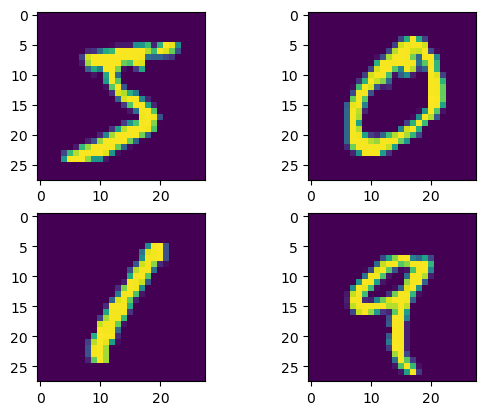

In [3]:
ax = plt.subplot(2,2,1)
ax.imshow(train_images[0,:,:])
ax1 = plt.subplot(2,2,2)
ax1.imshow(train_images[1,:,:])
ax2 = plt.subplot(2,2,3)
ax2.imshow(train_images[3,:,:])
ax3 = plt.subplot(2,2,4)
ax3.imshow(train_images[4,:,:])

We build our deep model with layers. 
- Takes image as input of matrix of pixels of size (28,28). It flattens the input image to a (784,) array.
- The next layer (1 hidden layer) is made up of 128 neurons. Each neuron consists of a scalar value calculated from $\sigma(\Sigma^{784}_{i,j=1}w_{ij}x_j+b)$. Here for each neuron there is a column vector $w$ which is of shape $(784,1)$ where each entry is a learnable parameter. and $(x)$ is the input of shape $(1*784)$. So in the hidden layer we have (784 + 1)*128 parameters. We call the output of this layer $\bold{h} = (h_1,h_2,....h_{128})$
- The next layer is our output layer. We take the 128 neuron values from the previous layer and map it to 10 neurons.It is a fully connected feed forward neural network so each 128 neurons fires at each of the 10 neurons. We have that the output for neuron one on output layer is given by: $$o_1 = w_{1,1}h_1+w_{2,1}h_2+w_{3,1}h_3+w_{4,1}h_{4}+\cdot+w_{128,1}h_{128}+b_1 = \Sigma^{128}_{j=1}w_{j1}h_j+b_1$$. There is currently no activation function on the output layer but if there was we would just have $\sigma(o_1)$ as output. Total parameters in this layer is (128+1)*10.
- Total parameters in whole network is (784+1)*128 + (128+1)*10 = 101770.

In [42]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten
import tensorflow as tf

# Generate data
x_train = train_images
y_train = train_labels

x_test = test_images
y_test = test_labels

# build the architecture with Sequential

model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10)])

# Compile the model, which involved shoows a loss function, an optimiser, and the performance metrics you want to track

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer='adam',loss=loss_fn,metrics=['accuracy'])

model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_7 (Flatten)         (None, 784)               0         
                                                                 
 dense_14 (Dense)            (None, 128)               100480    
                                                                 
 dense_15 (Dense)            (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


The loss_fn is using Categorical Cross Entropy and has from_logits=True which just means that the output of the neural network is not a distribution since softmax is not used on output layer. So the loss function changes the output to a probability distribution i.e sum to one. Scaling with $\frac{e^{o_i}}{\Sigma^{10}_{i=1}e^{o_i}}$ and then using the loss function $L=-log(p_y)$ where $p_y$ corresponds to the entry on the output corresonding to the probability of getting the true output $y$. We then minimise this Loss function which will result in $p_y \rightarrow 1$


The default batch size when we do model.fit is 32. this divides the 60000 training images into 60,000/32 = 1875 batches. In each batch the parameters are updated by the adam optimizer which moves the parameters in the opposite direction of the gradient. 

Prediction of neural network without any training = 6
Epoch 1/2
1875/1875 [==============================] - 7s 3ms/step - loss: 2.3889 - accuracy: 0.8597
Epoch 2/2
1875/1875 [==============================] - 5s 2ms/step - loss: 0.3893 - accuracy: 0.9059
313/313 - 1s - loss: 0.3855 - accuracy: 0.9116 - 1s/epoch - 4ms/step
Prediction of neural network with 1 epoch = 5


Text(0.5, 1.0, 'Actual Training data')

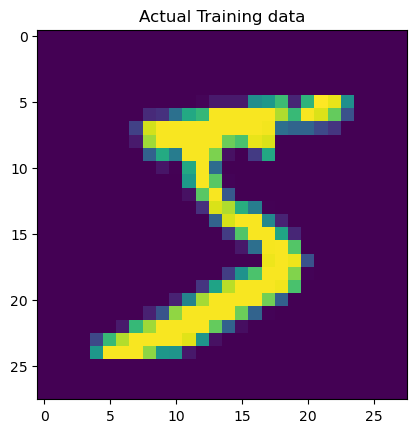

In [ ]:
logits = model(x_train[:1,:,:])          
probs = tf.nn.softmax(logits)        
prediction = np.argmax(probs)        
print("Prediction of neural network without any training =", prediction)
plt.imshow(x_train[0,:,:])

model.fit(x_train, y_train, batch_size = 32, epochs=2)

model.evaluate(x_test,  y_test, verbose=2)
logits_1 = model(x_train[:1,:,:])
probs_1 = tf.nn.softmax(logits_1) 
prediction_1 = np.argmax(probs_1)        
print("Prediction of neural network with 1 epoch =", prediction_1)


plt.imshow(x_train[0,:,:])
plt.title("Actual Training data")

## Interatction Between Detph and Width

Learning a piecewise smooth function from sample values

Epoch 1/20
313/313 [==============================] - 4s 7ms/step - loss: 0.0641 - mse: 0.0641
Epoch 2/20
313/313 [==============================] - 1s 4ms/step - loss: 0.0172 - mse: 0.0172
Epoch 3/20
313/313 [==============================] - 1s 4ms/step - loss: 0.0043 - mse: 0.0043
Epoch 4/20
313/313 [==============================] - 1s 4ms/step - loss: 0.0033 - mse: 0.0033
Epoch 5/20
313/313 [==============================] - 1s 3ms/step - loss: 0.0024 - mse: 0.0024
Epoch 6/20
313/313 [==============================] - 1s 3ms/step - loss: 0.0029 - mse: 0.0029
Epoch 7/20
313/313 [==============================] - 1s 3ms/step - loss: 0.0024 - mse: 0.0024
Epoch 8/20
313/313 [==============================] - 1s 5ms/step - loss: 0.0020 - mse: 0.0020
Epoch 9/20
313/313 [==============================] - 1s 5ms/step - loss: 0.0032 - mse: 0.0032
Epoch 10/20
313/313 [==============================] - 1s 5ms/step - loss: 0.0029 - mse: 0.0029
Epoch 11/20
313/313 [============================

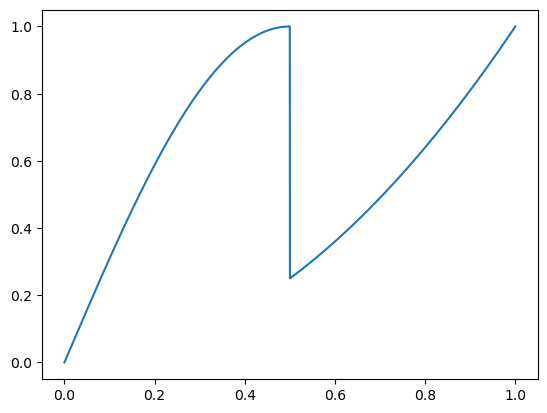

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

train_samples=10000

x_train=np.expand_dims(np.sort(np.random.uniform(0,1,train_samples)), 1)

#generate samples of y=sin(x * pi) for x\in[0,1) and y=x^2 for x\in[1/2,1]
def test_func(x):
    return np.sin(x*np.pi)*(x<1/2) + x**2*(x>=1/2)

y_train=test_func(x_train)

#uncommenting the below shows the samples
plt.figure()
plt.plot(x_train,y_train)

#we now train a network base on the samples (x_train,y_train) and evaluate it on x_test.

#consider varying the network width and depth,
#width and depth are controlled through the variables "width" and "depths respectively",

width=10
depth=10

model = Sequential()
model.add(Dense(width, input_dim=1, activation='relu'))

for i in range(depth-2):
  model.add(Dense(width, activation='relu'))

model.add(Dense(1))

model.compile(loss=tf.keras.losses.MeanSquaredError(), optimizer = 'adam',  metrics=['mse'])

model.fit(x_train, y_train, epochs=20, batch_size=32,verbose=1)

scores = model.evaluate(X, y)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

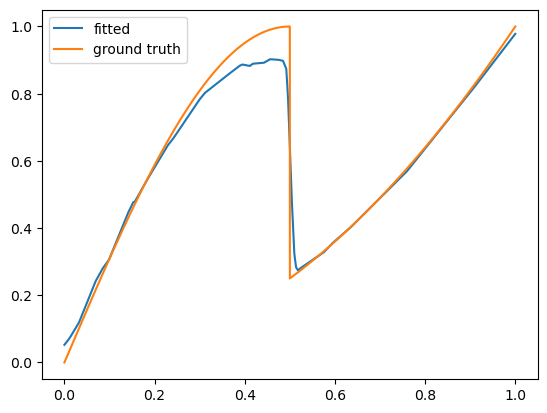

In [69]:
x_test=np.linspace(0,1,10000)
y_test = test_func(x_test)

x_test = np.expand_dims(x_test,  axis=1)
y_test_estimate = model(x_test)

plt.figure()
plt.plot(x_test,y_test_estimate, label = "fitted")
plt.plot(x_test, y_test, label = "ground truth")
plt.legend()